# Sinapsa — Brussels ↔ Chișinău weather bridge

## New geographic scope

We no longer fetch every Belgian commune.

### Belgium
We use **11 geographic areas**:
- Brussels-Capital Region
- 10 provinces

For weather, each area is represented by a reference city:
Brussels, Antwerp, Hasselt, Ghent, Bruges, Leuven, Mons, Liège, Arlon, Namur and Wavre.

### Moldova
We use:
- 32 raion centres
- Chișinău municipality
- Bălți municipality
- Comrat for Gagauzia

That gives **35 Moldovan reference centres**.

### Total
- Belgium: 11
- Moldova: 35
- Total: 46 locations
- 7-day forecast: 46 × 7 = **322 forecast rows**

The default public comparison remains:

**Brussels ↔ Chișinău**


## 1. Imports and API addresses

We now use only:
- `requests` for API calls;
- `pandas` for the table;
- `matplotlib` / `seaborn` for charts;
- Open-Meteo Geocoding API for coordinates;
- Open-Meteo Forecast API for weather.

The ODWB commune API is no longer needed for this version.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

GEOCODING_URL = "https://geocoding-api.open-meteo.com/v1/search"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"


## 2. Define the 46 reference areas

The `area` is what we want to show to the user.

The `representative_city` is the city whose coordinates will be used for the weather forecast.

This distinction is important:

> We are showing **weather at a representative regional centre**, not an average weather value for the whole province or raion.


In [2]:
reference_areas = [
    # --------------------------------------------------
    # BELGIUM — Brussels-Capital + 10 provinces
    # --------------------------------------------------
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Region",
        "area": "Brussels-Capital Region",
        "representative_city": "Brussels",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Antwerp Province",
        "representative_city": "Antwerp",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Limburg Province",
        "representative_city": "Hasselt",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "East Flanders Province",
        "representative_city": "Ghent",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "West Flanders Province",
        "representative_city": "Bruges",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Flemish Brabant Province",
        "representative_city": "Leuven",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Hainaut Province",
        "representative_city": "Mons",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Liège Province",
        "representative_city": "Liège",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Luxembourg Province",
        "representative_city": "Arlon",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Namur Province",
        "representative_city": "Namur",
    },
    {
        "country": "Belgium",
        "country_code": "BE",
        "area_type": "Province",
        "area": "Walloon Brabant Province",
        "representative_city": "Wavre",
    },

    # --------------------------------------------------
    # MOLDOVA — municipalities / Gagauzia / 32 raion centres
    # --------------------------------------------------
    {
        "country": "Moldova",
        "country_code": "MD",
        "area_type": "Municipality",
        "area": "Chișinău Municipality",
        "representative_city": "Chișinău",
    },
    {
        "country": "Moldova",
        "country_code": "MD",
        "area_type": "Municipality",
        "area": "Bălți Municipality",
        "representative_city": "Bălți",
    },
    {
        "country": "Moldova",
        "country_code": "MD",
        "area_type": "Autonomous territorial unit",
        "area": "Gagauzia",
        "representative_city": "Comrat",
    },

    # 32 raion centres
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Anenii Noi Raion", "representative_city": "Anenii Noi"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Basarabeasca Raion", "representative_city": "Basarabeasca"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Briceni Raion", "representative_city": "Briceni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Cahul Raion", "representative_city": "Cahul"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Călărași Raion", "representative_city": "Călărași"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Cantemir Raion", "representative_city": "Cantemir"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Căușeni Raion", "representative_city": "Căușeni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Cimișlia Raion", "representative_city": "Cimișlia"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Criuleni Raion", "representative_city": "Criuleni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Dondușeni Raion", "representative_city": "Dondușeni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Drochia Raion", "representative_city": "Drochia"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Dubăsari Raion", "representative_city": "Cocieri"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Edineț Raion", "representative_city": "Edineț"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Fălești Raion", "representative_city": "Fălești"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Florești Raion", "representative_city": "Florești"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Glodeni Raion", "representative_city": "Glodeni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Hîncești Raion", "representative_city": "Hîncești"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Ialoveni Raion", "representative_city": "Ialoveni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Leova Raion", "representative_city": "Leova"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Nisporeni Raion", "representative_city": "Nisporeni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Ocnița Raion", "representative_city": "Ocnița"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Orhei Raion", "representative_city": "Orhei"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Rezina Raion", "representative_city": "Rezina"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Rîșcani Raion", "representative_city": "Rîșcani"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Sîngerei Raion", "representative_city": "Sîngerei"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Soroca Raion", "representative_city": "Soroca"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Strășeni Raion", "representative_city": "Strășeni"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Șoldănești Raion", "representative_city": "Șoldănești"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Ștefan Vodă Raion", "representative_city": "Ștefan Vodă"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Taraclia Raion", "representative_city": "Taraclia"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Telenești Raion", "representative_city": "Telenești"},
    {"country": "Moldova", "country_code": "MD", "area_type": "Raion", "area": "Ungheni Raion", "representative_city": "Ungheni"},
]

print("Reference areas:", len(reference_areas))
print("Expected:", 46)


Reference areas: 46
Expected: 46


## 3. Geocode one representative city

Instead of storing coordinates manually, we ask the Open-Meteo Geocoding API.

The `countryCode` parameter prevents confusion between cities with similar names in different countries.


In [3]:
def geocode_location(city, country_code):
    params = {
        "name": city,
        "count": 1,
        "language": "en",
        "format": "json",
        "countryCode": country_code,
    }

    response = requests.get(
        GEOCODING_URL,
        params=params,
        timeout=20,
    )

    response.raise_for_status()
    data = response.json()

    if "results" not in data or len(data["results"]) == 0:
        raise ValueError(
            f"No geocoding result found for {city} ({country_code})"
        )

    result = data["results"][0]

    return {
        "latitude": result["latitude"],
        "longitude": result["longitude"],
        "timezone": result.get("timezone"),
        "geocoded_name": result.get("name"),
    }


## 4. Test geocoding with the default pair

Before geocoding all 46 centres, test only:

- Brussels
- Chișinău


In [4]:
brussels_geo = geocode_location("Brussels", "BE")
chisinau_geo = geocode_location("Chișinău", "MD")

print("Brussels:", brussels_geo)
print("Chișinău:", chisinau_geo)


Brussels: {'latitude': 50.85045, 'longitude': 4.34878, 'timezone': 'Europe/Brussels', 'geocoded_name': 'Brussels'}
Chișinău: {'latitude': 47.00902, 'longitude': 28.85938, 'timezone': 'Europe/Chisinau', 'geocoded_name': 'Chișinău'}


## 5. Geocode all 46 reference centres

This creates a clean location table.

If one place cannot be found, the `try/except` block records the error instead of stopping the whole notebook.


In [5]:
location_records = []

for area in reference_areas:
    try:
        geo = geocode_location(
            area["representative_city"],
            area["country_code"],
        )

        record = {
            **area,
            "latitude": geo["latitude"],
            "longitude": geo["longitude"],
            "timezone": geo["timezone"],
            "geocoded_name": geo["geocoded_name"],
            "geocoding_status": "OK",
        }

    except Exception as error:
        record = {
            **area,
            "latitude": None,
            "longitude": None,
            "timezone": None,
            "geocoded_name": None,
            "geocoding_status": str(error),
        }

    location_records.append(record)

df_locations = pd.DataFrame(location_records)

print("Locations:", len(df_locations))
print("Successfully geocoded:", df_locations["latitude"].notna().sum())

df_locations


Locations: 46
Successfully geocoded: 46


,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status
0,Belgium,BE,Region,Brussels-Capital Region,Brussels,50.85045,4.34878,Europe/Brussels,Brussels,OK
1,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,Europe/Brussels,Antwerp,OK
2,Belgium,BE,Province,Limburg Province,Hasselt,50.93106,5.33781,Europe/Brussels,Hasselt,OK
3,Belgium,BE,Province,East Flanders Province,Ghent,51.05000,3.71667,Europe/Brussels,Ghent,OK
4,Belgium,BE,Province,West Flanders Province,Bruges,51.20892,3.22424,Europe/Brussels,Bruges,OK
5,Belgium,BE,Province,Flemish Brabant Province,Leuven,50.87959,4.70093,Europe/Brussels,Leuven,OK
6,Belgium,BE,Province,Hainaut Province,Mons,50.45413,3.95229,Europe/Brussels,Mons,OK
7,Belgium,BE,Province,Liège Province,Liège,50.63373,5.56749,Europe/Brussels,Liège,OK
8,Belgium,BE,Province,Luxembourg Province,Arlon,49.68333,5.81667,Europe/Brussels,Arlon,OK
9,Belgium,BE,Province,Namur Province,Namur,50.46690,4.86746,Europe/Brussels,Namur,OK


## 6. Check for geocoding problems

The next cell shows only rows where coordinates were not found.

If the result is an empty DataFrame, all 46 locations were successfully geocoded.


In [6]:
geocoding_errors = df_locations[
    df_locations["latitude"].isna()
]

geocoding_errors


,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status


## 7. Weather-code descriptions

Open-Meteo returns numerical WMO weather codes.

We translate them into readable text for the chart and later for the website.


In [7]:
weather_descriptions = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Light rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Light snow",
    73: "Moderate snow",
    75: "Heavy snow",
    77: "Snow grains",
    80: "Light rain showers",
    81: "Moderate rain showers",
    82: "Heavy rain showers",
    85: "Light snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with light hail",
    99: "Thunderstorm with heavy hail",
}


## 8. Function: get a 7-day forecast

Input:
- one row from `df_locations`

Output:
- 7 dictionaries, one per forecast day.


In [8]:
def get_weather(location):
    weather_params = {
        "latitude": location["latitude"],
        "longitude": location["longitude"],
        "daily": (
            "temperature_2m_max,"
            "temperature_2m_min,"
            "precipitation_sum,"
            "precipitation_probability_max,"
            "weather_code"
        ),
        "timezone": "auto",
        "forecast_days": 7,
    }

    response = requests.get(
        FORECAST_URL,
        params=weather_params,
        timeout=20,
    )

    response.raise_for_status()
    weather_data = response.json()
    daily = weather_data["daily"]

    records = []

    for i in range(len(daily["time"])):
        records.append({
            "country": location["country"],
            "country_code": location["country_code"],
            "area_type": location["area_type"],
            "area": location["area"],
            "representative_city": location["representative_city"],
            "latitude": location["latitude"],
            "longitude": location["longitude"],
            "date": daily["time"][i],
            "temp_min": daily["temperature_2m_min"][i],
            "temp_max": daily["temperature_2m_max"][i],
            "precipitation_mm": daily["precipitation_sum"][i],
            "precipitation_probability": daily[
                "precipitation_probability_max"
            ][i],
            "weather_code": daily["weather_code"][i],
        })

    return records


## 9. Test weather with Brussels only

We still test the function with one location before processing all 46.


In [9]:
brussels_location = df_locations[
    df_locations["area"] == "Brussels-Capital Region"
].iloc[0]

brussels_forecast = get_weather(brussels_location)

print("Forecast rows:", len(brussels_forecast))
print(brussels_forecast[0])


Forecast rows: 7
{'country': 'Belgium', 'country_code': 'BE', 'area_type': 'Region', 'area': 'Brussels-Capital Region', 'representative_city': 'Brussels', 'latitude': np.float64(50.85045), 'longitude': np.float64(4.34878), 'date': '2026-08-20', 'temp_min': 15.5, 'temp_max': 21.7, 'precipitation_mm': 0.2, 'precipitation_probability': 100, 'weather_code': 51}


## 10. Get weather for all successfully geocoded areas

Expected if all 46 locations are valid:

**46 × 7 = 322 rows**


In [10]:
all_forecasts = []

valid_locations = df_locations.dropna(
    subset=["latitude", "longitude"]
)

for _, location in valid_locations.iterrows():
    forecast = get_weather(location)
    all_forecasts.extend(forecast)

df_weather = pd.DataFrame(all_forecasts)

df_weather["date"] = pd.to_datetime(
    df_weather["date"]
)

df_weather["weather"] = (
    df_weather["weather_code"]
    .map(weather_descriptions)
    .fillna("Unknown")
)

df_weather = (
    df_weather
    .sort_values(["country", "area", "date"])
    .reset_index(drop=True)
)

print("Areas processed:", df_weather["area"].nunique())
print("Forecast rows:", len(df_weather))
print("Expected if 46 areas succeeded:", 46 * 7)

df_weather.head()


Areas processed: 46
Forecast rows: 322
Expected if 46 areas succeeded: 322


,country,country_code,area_type,area,representative_city,latitude,longitude,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather_code,weather
0,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-20,15.8,21.0,1.5,100,53,Moderate drizzle
1,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-21,14.8,20.0,10.4,100,63,Moderate rain
2,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-22,14.4,19.8,5.7,59,63,Moderate rain
3,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-23,12.3,19.8,0.8,12,51,Light drizzle
4,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-24,12.1,21.1,0.0,16,2,Partly cloudy


## 11. Basic quality checks

Before visualization, verify:
- how many Belgian areas were processed;
- how many Moldovan areas were processed;
- whether important fields contain missing values.


In [11]:
print(
    "Belgium areas:",
    df_weather.loc[
        df_weather["country"] == "Belgium",
        "area"
    ].nunique()
)

print(
    "Moldova areas:",
    df_weather.loc[
        df_weather["country"] == "Moldova",
        "area"
    ].nunique()
)

print()
print("Missing values:")
print(
    df_weather[
        [
            "area",
            "representative_city",
            "date",
            "temp_min",
            "temp_max",
            "precipitation_mm",
            "weather",
        ]
    ].isna().sum()
)


Belgium areas: 11
Moldova areas: 35

Missing values:
area                   0
representative_city    0
date                   0
temp_min               0
temp_max               0
precipitation_mm       0
weather                0
dtype: int64


## 12. Function: plot one regional centre

The title shows both:
- the administrative area;
- the representative weather city.

Example:

`7-day forecast — Ungheni Raion (Ungheni)`


In [12]:
def plot_weather(area_name, data):
    data = data.sort_values("date")

    city = data["representative_city"].iloc[0]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(
        data["date"],
        data["temp_min"],
        marker="o",
        label="Minimum temperature",
    )

    ax1.plot(
        data["date"],
        data["temp_max"],
        marker="o",
        label="Maximum temperature",
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_title(
        f"7-day forecast — {area_name} ({city})"
    )

    for date, temp, weather in zip(
        data["date"],
        data["temp_max"],
        data["weather"],
    ):
        ax1.annotate(
            weather,
            (date, temp),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    ax2 = ax1.twinx()

    ax2.bar(
        data["date"],
        data["precipitation_mm"],
        alpha=0.3,
        label="Precipitation",
    )

    ax2.set_ylabel("Precipitation (mm)")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    ax1.tick_params(
        axis="x",
        rotation=45,
    )

    plt.tight_layout()
    plt.show()


## 13. Default Sinapsa view: Brussels ↔ Chișinău

This is the default public pair we want to keep.

For now the notebook displays two charts.
Later the website can present them side by side.


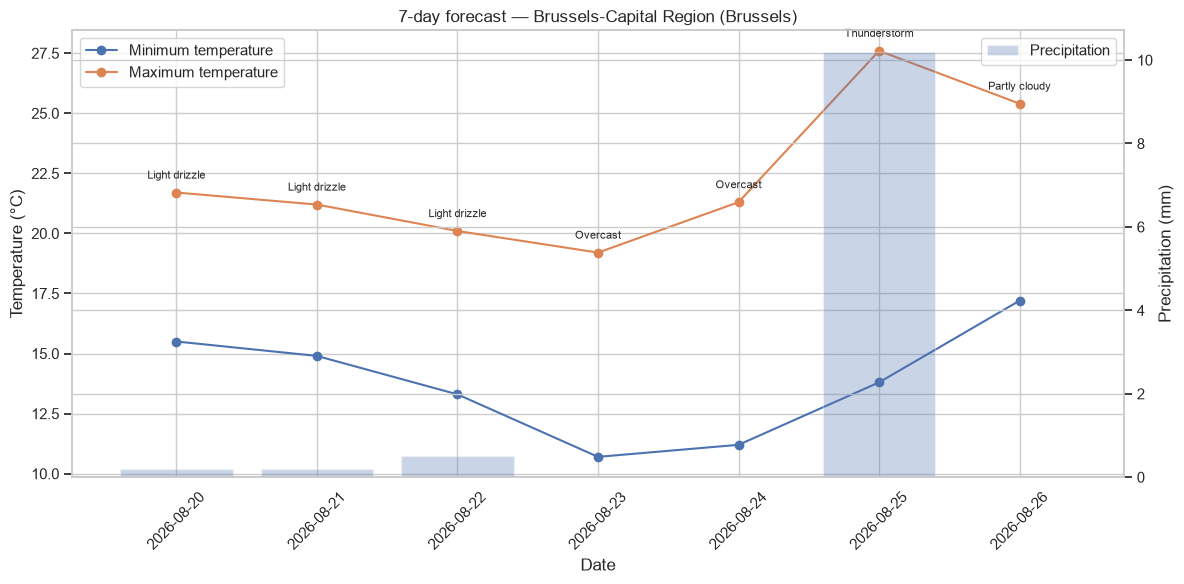

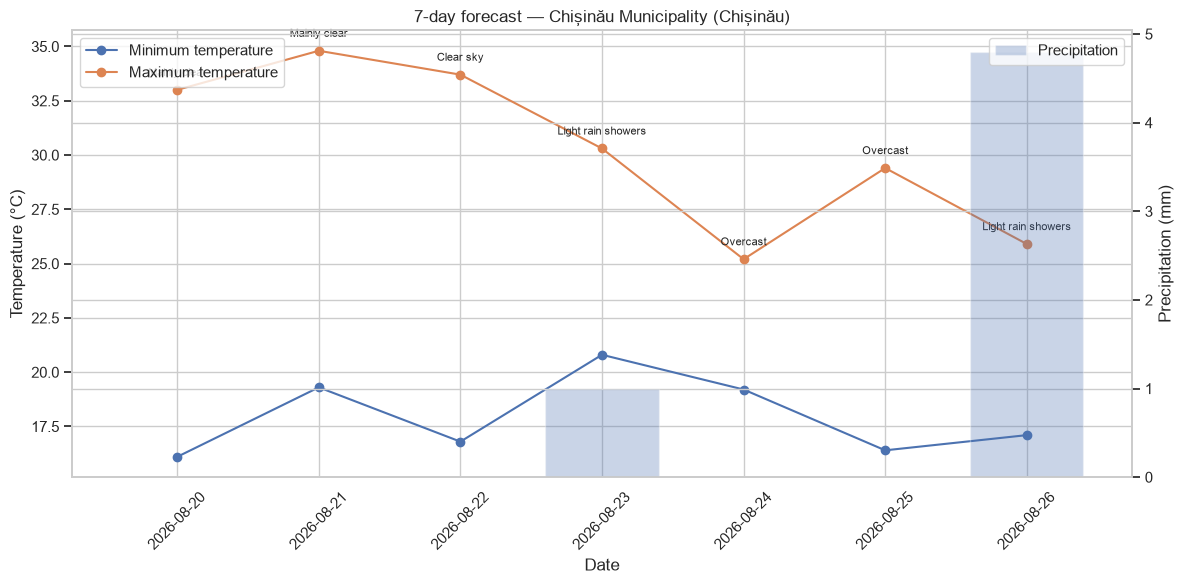

In [13]:
default_areas = [
    "Brussels-Capital Region",
    "Chișinău Municipality",
]

for area_name in default_areas:
    data = df_weather[
        df_weather["area"] == area_name
    ]

    plot_weather(
        area_name,
        data,
    )


## 14. Test another regional pair

Example:

**Liège Province ↔ Ungheni Raion**

Change the two names below to test other combinations.


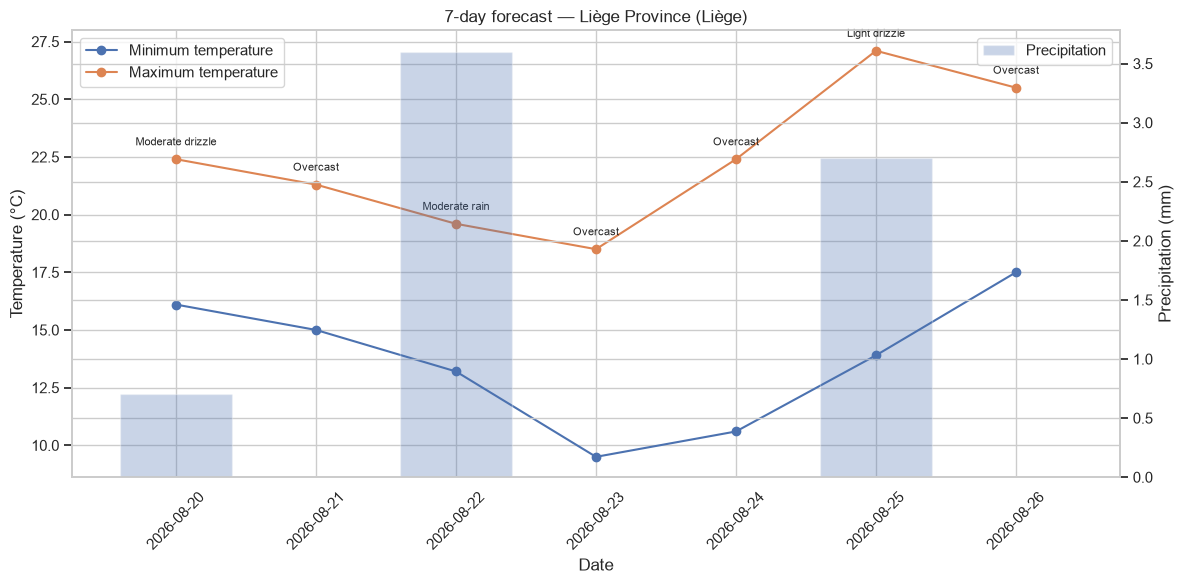

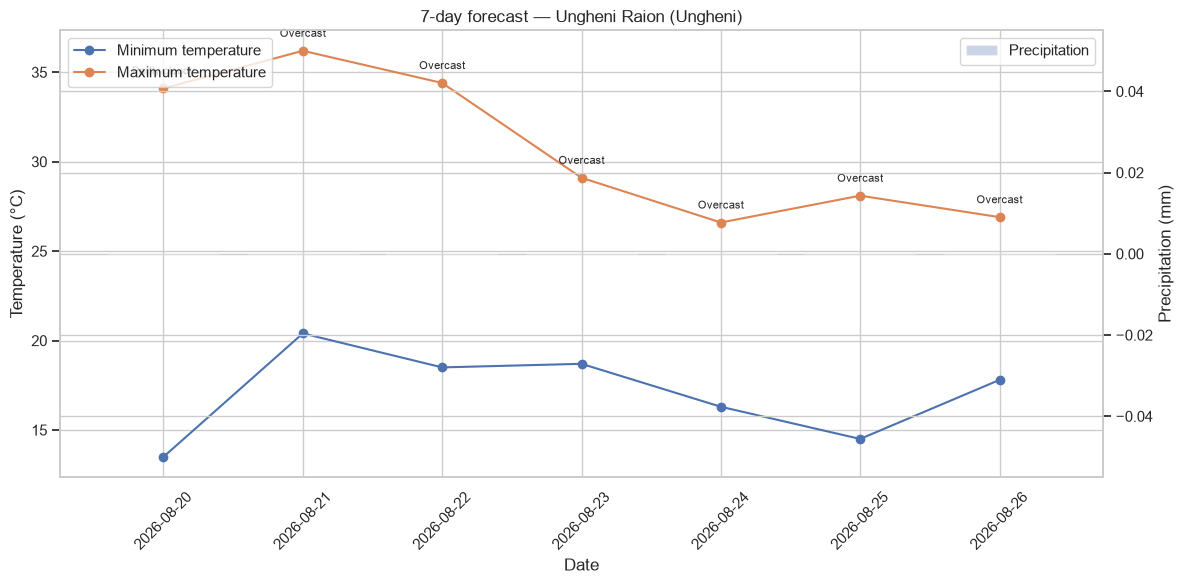

In [14]:
selected_belgium_area = "Liège Province"
selected_moldova_area = "Ungheni Raion"

for area_name in [
    selected_belgium_area,
    selected_moldova_area,
]:
    data = df_weather[
        df_weather["area"] == area_name
    ]

    plot_weather(
        area_name,
        data,
    )


# New pipeline

```text
46 reference areas
      ↓
representative city
      ↓
Open-Meteo Geocoding
      ↓
latitude + longitude
      ↓
Open-Meteo Forecast
      ↓
7 days × 46 locations
      ↓
Pandas
      ↓
322 forecast rows
      ↓
Brussels ↔ Chișinău default
      ↓
optional regional comparison
```

## What we deliberately removed

We no longer need:

```text
ODWB
↓
all Belgian communes
↓
pagination
```

because Sinapsa's current scope is regional rather than commune-level.

## Next logical step

Once this notebook runs correctly from top to bottom:

1. save the 46 geocoded locations so they do not need to be geocoded every run;
2. save the forecast table to CSV;
3. later store it through SQLAlchemy;
4. connect Brussels ↔ Chișinău to the website.


In [15]:
# Save the reference locations to a CSV file.
#
# index=False prevents Pandas from adding an unnecessary
# extra column with row numbers.

df_locations.to_csv(
    "sinapsa_locations.csv",
    index=False
)

print("File saved: sinapsa_locations.csv")

File saved: sinapsa_locations.csv


In [16]:
# Read the saved CSV file back into Pandas.

df_locations_saved = pd.read_csv(
    "sinapsa_locations.csv"
)

print("Rows loaded:", len(df_locations_saved))

df_locations_saved.head()

Rows loaded: 46


,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status
0,Belgium,BE,Region,Brussels-Capital Region,Brussels,50.85045,4.34878,Europe/Brussels,Brussels,OK
1,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,Europe/Brussels,Antwerp,OK
2,Belgium,BE,Province,Limburg Province,Hasselt,50.93106,5.33781,Europe/Brussels,Hasselt,OK
3,Belgium,BE,Province,East Flanders Province,Ghent,51.05000,3.71667,Europe/Brussels,Ghent,OK
4,Belgium,BE,Province,West Flanders Province,Bruges,51.20892,3.22424,Europe/Brussels,Bruges,OK


In [ ]:
# Check the Brussels reference record.

df_locations_saved[
    df_locations_saved["representative_city"] == "Brussels"
]



,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status
11,Moldova,MD,Municipality,Chișinău Municipality,Chișinău,47.00902,28.85938,Europe/Chisinau,Chișinău,OK


In [19]:
# Check the Chișinău reference record.

df_locations_saved[
    df_locations_saved["representative_city"] == "Chișinău"
]

,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status
11,Moldova,MD,Municipality,Chișinău Municipality,Chișinău,47.00902,28.85938,Europe/Chisinau,Chișinău,OK


In [20]:
df_locations = pd.read_csv("sinapsa_locations.csv")

In [24]:
# Save the complete 7-day weather forecast.
#
# We expect:
# 46 locations × 7 days = 322 rows.

df_weather.to_csv(
    "sinapsa_weather.csv",
    index=False
)

print("File saved: sinapsa_weather.csv")
print("Rows saved:", len(df_weather))

File saved: sinapsa_weather.csv
Rows saved: 322


In [25]:
# Load the saved weather file again.
# This verifies that the file can be reused independently
# of the API request.

df_weather_saved = pd.read_csv(
    "sinapsa_weather.csv"
)

print("Rows loaded:", len(df_weather_saved))
print("Columns:", len(df_weather_saved.columns))

df_weather_saved.head()

Rows loaded: 322
Columns: 14


,country,country_code,area_type,area,representative_city,latitude,longitude,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather_code,weather
0,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-20,15.8,21.0,1.5,100,53,Moderate drizzle
1,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-21,14.8,20.0,10.4,100,63,Moderate rain
2,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-22,14.4,19.8,5.7,59,63,Moderate rain
3,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-23,12.3,19.8,0.8,12,51,Light drizzle
4,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,2026-08-24,12.1,21.1,0.0,16,2,Partly cloudy


In [26]:
print(
    "Belgium rows:",
    len(
        df_weather_saved[
            df_weather_saved["country"] == "Belgium"
        ]
    )
)

print(
    "Moldova rows:",
    len(
        df_weather_saved[
            df_weather_saved["country"] == "Moldova"
        ]
    )
)

Belgium rows: 77
Moldova rows: 245


In [27]:
# SQLAlchemy lets Python communicate with SQL databases.

from sqlalchemy import create_engine

In [28]:
# Create a connection to a local SQLite database.
#
# If sinapsa.db does not exist yet,
# SQLite will create it automatically.

engine = create_engine(
    "sqlite:///sinapsa.db"
)

print("Database engine created.")

Database engine created.


In [29]:
df_locations.to_sql(
    name="locations",
    con=engine,
    if_exists="replace",
    index=False
)

print("Table 'locations' created.")

Table 'locations' created.


In [30]:
# Read the SQL table back into Pandas.

df_locations_sql = pd.read_sql(
    "SELECT * FROM locations",
    con=engine
)

print("Rows read from SQL:", len(df_locations_sql))

df_locations_sql.head()

Rows read from SQL: 46


,country,country_code,area_type,area,representative_city,latitude,longitude,timezone,geocoded_name,geocoding_status
0,Belgium,BE,Region,Brussels-Capital Region,Brussels,50.85045,4.34878,Europe/Brussels,Brussels,OK
1,Belgium,BE,Province,Antwerp Province,Antwerp,51.22047,4.40026,Europe/Brussels,Antwerp,OK
2,Belgium,BE,Province,Limburg Province,Hasselt,50.93106,5.33781,Europe/Brussels,Hasselt,OK
3,Belgium,BE,Province,East Flanders Province,Ghent,51.05000,3.71667,Europe/Brussels,Ghent,OK
4,Belgium,BE,Province,West Flanders Province,Bruges,51.20892,3.22424,Europe/Brussels,Bruges,OK


In [31]:
# Save the complete weather DataFrame
# into a SQL table called weather_forecast.

df_weather.to_sql(
    name="weather_forecast",
    con=engine,
    if_exists="replace",
    index=False
)

print("Table 'weather_forecast' created.")
print("Rows written:", len(df_weather))

Table 'weather_forecast' created.
Rows written: 322


In [32]:
# SQL query:
# count how many rows exist in weather_forecast.

query = """
SELECT COUNT(*) AS number_of_rows
FROM weather_forecast;
"""

result = pd.read_sql(
    query,
    con=engine
)

result

,number_of_rows
0,322


In [33]:
# Retrieve only the Brussels forecast from SQL.

query_brussels = """
SELECT
    area,
    representative_city,
    date,
    temp_min,
    temp_max,
    precipitation_mm,
    precipitation_probability,
    weather
FROM weather_forecast
WHERE representative_city = 'Brussels'
ORDER BY date;
"""

df_brussels_sql = pd.read_sql(
    query_brussels,
    con=engine
)

df_brussels_sql

,area,representative_city,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Brussels-Capital Region,Brussels,2026-08-20 00:00:00.000000,15.5,21.7,0.2,100,Light drizzle
1,Brussels-Capital Region,Brussels,2026-08-21 00:00:00.000000,14.9,21.2,0.2,100,Light drizzle
2,Brussels-Capital Region,Brussels,2026-08-22 00:00:00.000000,13.3,20.1,0.5,65,Light drizzle
3,Brussels-Capital Region,Brussels,2026-08-23 00:00:00.000000,10.7,19.2,0.0,8,Overcast
4,Brussels-Capital Region,Brussels,2026-08-24 00:00:00.000000,11.2,21.3,0.0,18,Overcast
5,Brussels-Capital Region,Brussels,2026-08-25 00:00:00.000000,13.8,27.6,10.2,42,Thunderstorm
6,Brussels-Capital Region,Brussels,2026-08-26 00:00:00.000000,17.2,25.4,0.0,22,Partly cloudy


In [34]:
# Retrieve only the Chișinău forecast from SQL.

query_chisinau = """
SELECT
    area,
    representative_city,
    date,
    temp_min,
    temp_max,
    precipitation_mm,
    precipitation_probability,
    weather
FROM weather_forecast
WHERE representative_city = 'Chișinău'
ORDER BY date;
"""

df_chisinau_sql = pd.read_sql(
    query_chisinau,
    con=engine
)

df_chisinau_sql

,area,representative_city,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Chișinău Municipality,Chișinău,2026-08-20 00:00:00.000000,16.1,33.0,0.0,0,Mainly clear
1,Chișinău Municipality,Chișinău,2026-08-21 00:00:00.000000,19.3,34.8,0.0,0,Mainly clear
2,Chișinău Municipality,Chișinău,2026-08-22 00:00:00.000000,16.8,33.7,0.0,0,Clear sky
3,Chișinău Municipality,Chișinău,2026-08-23 00:00:00.000000,20.8,30.3,1.0,28,Light rain showers
4,Chișinău Municipality,Chișinău,2026-08-24 00:00:00.000000,19.2,25.2,0.0,8,Overcast
5,Chișinău Municipality,Chișinău,2026-08-25 00:00:00.000000,16.4,29.4,0.0,18,Overcast
6,Chișinău Municipality,Chișinău,2026-08-26 00:00:00.000000,17.1,25.9,4.8,40,Light rain showers


In [35]:
# Retrieve the default Sinapsa pair:
# Brussels + Chișinău.

query_bridge = """
SELECT
    country,
    area,
    representative_city,
    date,
    temp_min,
    temp_max,
    precipitation_mm,
    precipitation_probability,
    weather
FROM weather_forecast
WHERE representative_city IN ('Brussels', 'Chișinău')
ORDER BY date, representative_city;
"""

df_bridge = pd.read_sql(
    query_bridge,
    con=engine
)

print("Rows returned:", len(df_bridge))

df_bridge

Rows returned: 14


,country,area,representative_city,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Belgium,Brussels-Capital Region,Brussels,2026-08-20 00:00:00.000000,15.5,21.7,0.2,100,Light drizzle
1,Moldova,Chișinău Municipality,Chișinău,2026-08-20 00:00:00.000000,16.1,33.0,0.0,0,Mainly clear
2,Belgium,Brussels-Capital Region,Brussels,2026-08-21 00:00:00.000000,14.9,21.2,0.2,100,Light drizzle
3,Moldova,Chișinău Municipality,Chișinău,2026-08-21 00:00:00.000000,19.3,34.8,0.0,0,Mainly clear
4,Belgium,Brussels-Capital Region,Brussels,2026-08-22 00:00:00.000000,13.3,20.1,0.5,65,Light drizzle
5,Moldova,Chișinău Municipality,Chișinău,2026-08-22 00:00:00.000000,16.8,33.7,0.0,0,Clear sky
6,Belgium,Brussels-Capital Region,Brussels,2026-08-23 00:00:00.000000,10.7,19.2,0.0,8,Overcast
7,Moldova,Chișinău Municipality,Chișinău,2026-08-23 00:00:00.000000,20.8,30.3,1.0,28,Light rain showers
8,Belgium,Brussels-Capital Region,Brussels,2026-08-24 00:00:00.000000,11.2,21.3,0.0,18,Overcast
9,Moldova,Chișinău Municipality,Chișinău,2026-08-24 00:00:00.000000,19.2,25.2,0.0,8,Overcast


In [36]:
# This function retrieves the 7-day forecast
# for one selected administrative area from the SQL database.

def get_forecast(area_name):

    query = """
    SELECT
        country,
        area,
        representative_city,
        date,
        temp_min,
        temp_max,
        precipitation_mm,
        precipitation_probability,
        weather
    FROM weather_forecast
    WHERE area = ?
    ORDER BY date;
    """

    result = pd.read_sql(
        query,
        con=engine,
        params=(area_name,)
    )

    return result

In [37]:
# Test the function with one Belgian area.

belgium_forecast = get_forecast(
    "Liège Province"
)

print("Rows:", len(belgium_forecast))

belgium_forecast


Rows: 7


,country,area,representative_city,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Belgium,Liège Province,Liège,2026-08-20 00:00:00.000000,16.1,22.4,0.7,85,Moderate drizzle
1,Belgium,Liège Province,Liège,2026-08-21 00:00:00.000000,15.0,21.3,0.0,99,Overcast
2,Belgium,Liège Province,Liège,2026-08-22 00:00:00.000000,13.2,19.6,3.6,58,Moderate rain
3,Belgium,Liège Province,Liège,2026-08-23 00:00:00.000000,9.5,18.5,0.0,6,Overcast
4,Belgium,Liège Province,Liège,2026-08-24 00:00:00.000000,10.6,22.4,0.0,14,Overcast
5,Belgium,Liège Province,Liège,2026-08-25 00:00:00.000000,13.9,27.1,2.7,49,Light drizzle
6,Belgium,Liège Province,Liège,2026-08-26 00:00:00.000000,17.5,25.5,0.0,22,Overcast


In [38]:
# Use exactly the same function for a Moldovan area.

moldova_forecast = get_forecast(
    "Soroca Raion"
)

print("Rows:", len(moldova_forecast))

moldova_forecast

Rows: 7


,country,area,representative_city,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Moldova,Soroca Raion,Soroca,2026-08-20 00:00:00.000000,12.7,31.6,0.0,0,Mainly clear
1,Moldova,Soroca Raion,Soroca,2026-08-21 00:00:00.000000,18.9,35.6,0.0,0,Clear sky
2,Moldova,Soroca Raion,Soroca,2026-08-22 00:00:00.000000,17.6,34.0,0.0,13,Overcast
3,Moldova,Soroca Raion,Soroca,2026-08-23 00:00:00.000000,17.5,26.8,0.1,28,Overcast
4,Moldova,Soroca Raion,Soroca,2026-08-24 00:00:00.000000,14.1,24.5,0.0,19,Overcast
5,Moldova,Soroca Raion,Soroca,2026-08-25 00:00:00.000000,12.0,26.3,0.0,15,Overcast
6,Moldova,Soroca Raion,Soroca,2026-08-26 00:00:00.000000,15.7,26.3,0.9,30,Overcast
